In [1]:
import pickle # enable the saving and loading of trained models for later use
import pathlib
from pathlib import Path
import shutil
import random
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import cv2
import PIL
import glob
from tensorflow import keras
from keras.models import Sequential, load_model
from tensorflow.keras.utils import image_dataset_from_directory #Generates a tf.data.Dataset from image files in a directory.
from keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense, Dropout, BatchNormalization, Rescaling, GlobalAveragePooling2D

# Transform features by scaling each feature to a given range.
from sklearn.preprocessing import Normalizer, MinMaxScaler
#Pipeline of transforms with a final estimator.
from sklearn.pipeline import Pipeline

#Import scikit-learn metrics module for accuracy calculation
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

from tensorflow.keras.optimizers import Adam

#train_test_split function
from sklearn.model_selection import train_test_split

In [10]:
new_folder = Path(r"datasets_split")
#new_folder.mkdir(parents=True, exist_ok=True)
#print("New folder created.")

output_dir = new_folder

In [11]:
img_data = []
label = []

IMG_HEIGHT = 180
IMG_WIDTH = 180

for i in os.listdir(output_dir):
    impath = os.path.join(output_dir,i)
    im = glob.glob(impath + '/*.jpeg')
    print(len(im))
    for j in im:
        img= cv2.imread(j)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_HEIGHT, IMG_WIDTH),interpolation = cv2.INTER_AREA)
        img=np.array(img)
        img = img.astype('float32')
        img_data.append(img)
        label.append(i)

25802
2438
5288
872
708


In [4]:
print(f"Amount of images: {len(img_data)}")
print(f"Amount of images: {len(label)}")

Amount of images: 35108
Amount of images: 35108


In [13]:
from pathlib import Path
import shutil
import random

original_dir = output_dir
new_dir = Path(r"datasets_undersample")
new_dir.mkdir(parents=True, exist_ok=True)

TARGET_PER_CLASS = 700
SEED = 42

random.seed(SEED)

for class_folder in sorted(original_dir.iterdir()):
    if class_folder.is_dir():
        class_name = class_folder.name
        output_class_folder = new_dir / class_name
        output_class_folder.mkdir(parents=True, exist_ok=True)

        # Get .jpeg files only
        image_files = list(class_folder.glob("*.jpeg"))

        print(f"{class_name}: found {len(image_files)} images")

        # Randomly choose 700 images if possible
        if len(image_files) > TARGET_PER_CLASS:
            selected_images = random.sample(image_files, TARGET_PER_CLASS)
        else:
            selected_images = image_files

        # Copy selected images
        for img_path in selected_images:
            destination_path = output_class_folder / img_path.name
            shutil.copy2(img_path, destination_path)

        print(f"{class_name}: copied {len(selected_images)} images")

print("Finished creating new dataset.")

class_0: found 25802 images
class_0: copied 700 images
class_1: found 2438 images
class_1: copied 700 images
class_2: found 5288 images
class_2: copied 700 images
class_3: found 872 images
class_3: copied 700 images
class_4: found 708 images
class_4: copied 700 images
Finished creating new dataset.


In [2]:
new_dir = Path(r"datasets_undersample")

In [3]:
img_data = []
label = []

IMG_HEIGHT = 180
IMG_WIDTH = 180

for i in os.listdir(new_dir):
    impath = os.path.join(new_dir,i)
    im = glob.glob(impath + '/*.jpeg')
    print(len(im))
    for j in im:
        img= cv2.imread(j)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_HEIGHT, IMG_WIDTH),interpolation = cv2.INTER_AREA)
        img=np.array(img)
        img = img.astype('float32')
        img_data.append(img)
        label.append(i)

700
700
700
700
700


In [4]:
print(f"Amount of images: {len(img_data)}")
print(f"Amount of images: {len(label)}")

Amount of images: 3500
Amount of images: 3500


In [4]:
vals, ids, y = np.unique(label, return_index=True, return_inverse=True)
print(vals)
print(y)

['class_0' 'class_1' 'class_2' 'class_3' 'class_4']
[0 0 0 ... 4 4 4]


3421
1356
1926
1035
2465
2909
116
55
2726


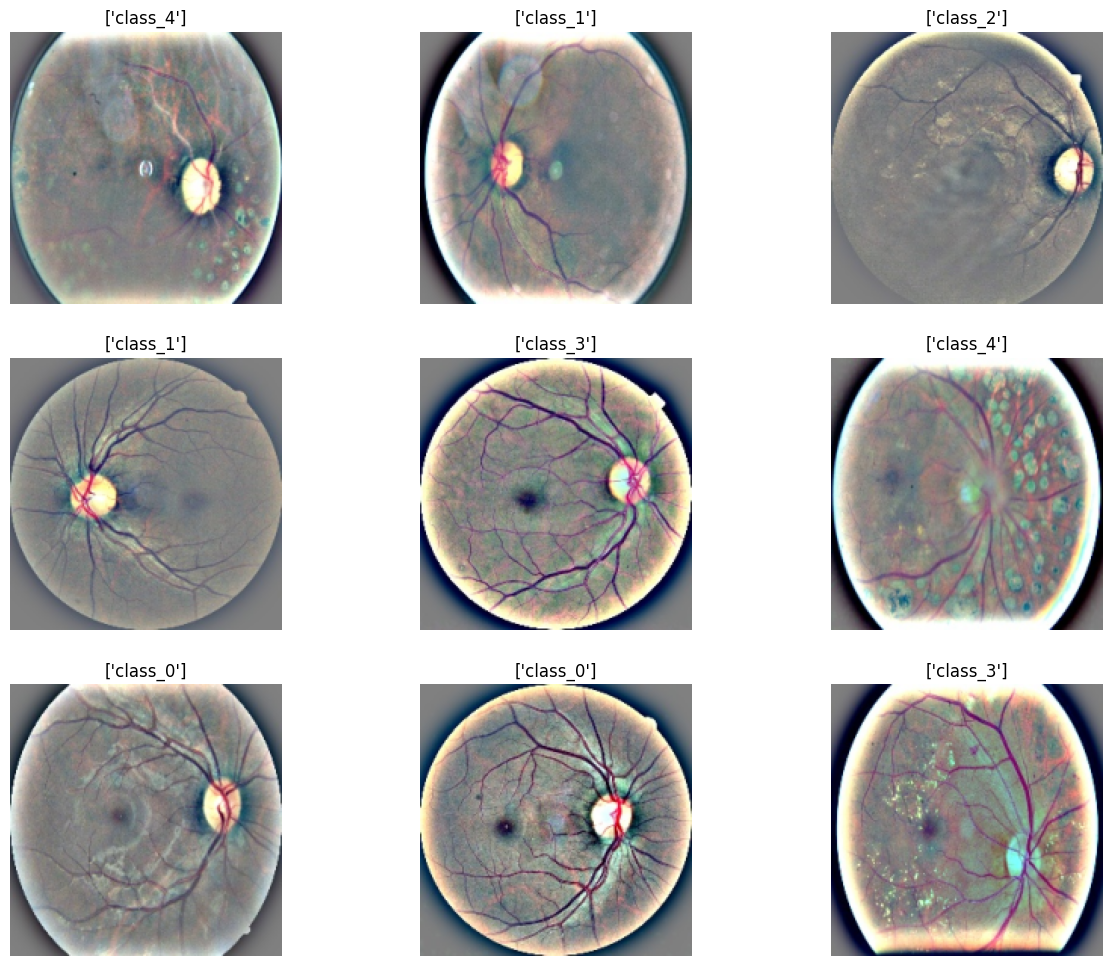

In [6]:
# visualize images loaded with the keras utility (image_dataset_from_directory)

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

for i in range(9):
    num=random.randint(0,3500)
    print(num)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(img_data[num].astype("uint8"))
    plt.title([label[num]])
    plt.axis("off")

In [5]:
  #Split dataset into 80% training 20% others
X_train, X_others, y_train, y_others = train_test_split(img_data, y, test_size=0.3, random_state=0, stratify=y)
#Split dataset into 50% training 50% testig
X_valid, X_test, y_valid, y_test = train_test_split(X_others, y_others, test_size=0.5, random_state=0, stratify=y_others)

In [6]:
    #reshaping for cnn
# defining the sets of train and test
X_train = np.array(X_train).reshape(-1, 180,180, 3)
X_valid = np.array(X_valid).reshape(-1, 180, 180, 3)
X_test = np.array(X_test).reshape(-1, 180, 180, 3)
X_train /= 255
X_valid/=255
X_test /= 255

print(X_train.shape)
print(X_test.shape)
print(X_valid.shape)
print(y_train.shape)
print(y_valid.shape)
print(y_test.shape)

(2450, 180, 180, 3)
(525, 180, 180, 3)
(525, 180, 180, 3)
(2450,)
(525,)
(525,)


**MODEL 4**

In [13]:
model4 = Sequential()
num_classes = 5
input_shape = X_train[0].shape

# Block 1
model4.add(Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=input_shape))
model4.add(BatchNormalization())
model4.add(Conv2D(32, (3, 3), padding="same", activation="relu"))
model4.add(BatchNormalization())
model4.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model4.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
model4.add(BatchNormalization())
model4.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
model4.add(BatchNormalization())
model4.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model4.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
model4.add(BatchNormalization())
model4.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
model4.add(BatchNormalization())
model4.add(MaxPooling2D(pool_size=(2, 2)))

# Classifier
model4.add(GlobalAveragePooling2D())
model4.add(Dense(128, activation="relu"))
model4.add(BatchNormalization())
model4.add(Dropout(0.4))
model4.add(Dense(num_classes, activation="softmax"))

model4.summary()

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 180, 180, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 90, 90, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 45, 45, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,469 (1.17 MB)

 Trainable params: 305,317 (1.16 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [15]:
model4.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
md4 = model4.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=10,
    batch_size=32
)

Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.2584 - loss: 1.9267 - val_accuracy: 0.1962 - val_loss: 1.6813
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.3167 - loss: 1.6890 - val_accuracy: 0.2019 - val_loss: 1.8367
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.3347 - loss: 1.6605 - val_accuracy: 0.1981 - val_loss: 3.0303
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.3588 - loss: 1.5628 - val_accuracy: 0.1943 - val_loss: 2.9413
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.3878 - loss: 1.4939 - val_accuracy: 0.2000 - val_loss: 4.1386
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 77s 997ms/step - accuracy: 0.3861 - loss: 1.4652 - val_accuracy: 0.2286 - val_loss: 3.7926
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 77s 1000ms/step - accuracy: 0.4082 - loss: 1.4139 - val_accuracy: 0.3333 - val_loss: 1.9775
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.4057 - loss: 1.3825 - val_accuracy: 0.2705 - va

In [ ]:
model4.save("models/CNNv4.keras")

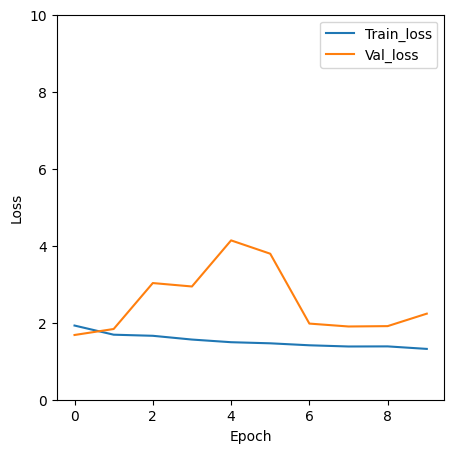

In [17]:
plt.rcParams["figure.figsize"] = (5,5)
plt.plot(md4.history['loss'], label='Train_loss')
plt.plot(md4.history['val_loss'], label='Val_loss')
plt.ylim([0, 10])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

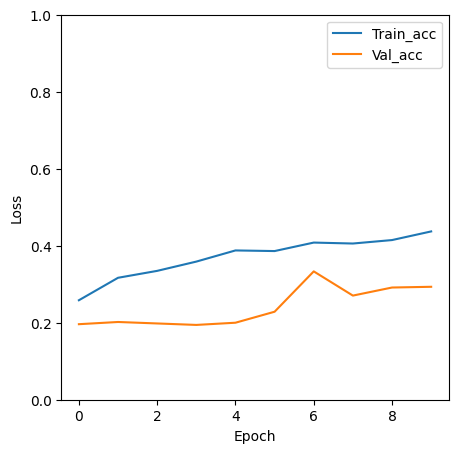

In [18]:
plt.rcParams["figure.figsize"] = (5,5)
plt.plot(md4.history['accuracy'], label='Train_acc')
plt.plot(md4.history['val_accuracy'], label='Val_acc')
plt.ylim([0, 1])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [19]:
y_pred = np.argmax(model4.predict(X_test), axis=-1)

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step


In [20]:
#Model Evaluation
print("Accuracy:",  accuracy_score(y_test, y_pred))
print("Precision Score : ",precision_score(y_test, y_pred, average='macro'))
print("Recall Score : ",recall_score(y_test, y_pred, average='macro'))
print("F1 Score : ",f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.26285714285714284
Precision Score :  0.15358372456964003
Recall Score :  0.26285714285714284
F1 Score :  0.18362906565314902


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [21]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       105
           1       0.00      0.00      0.00       105
           2       0.17      0.10      0.12       105
           3       0.19      0.51      0.28       105
           4       0.41      0.70      0.52       105

    accuracy                           0.26       525
   macro avg       0.15      0.26      0.18       525
weighted avg       0.15      0.26      0.18       525

[[ 0  0 19 71 15]
 [ 1  0 25 63 16]
 [ 0  0 10 65 30]
 [ 0  0  6 54 45]
 [ 0  0  0 31 74]]


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

MODEL 4

In [9]:
model4 = Sequential()
num_classes = 5
input_shape = X_train[0].shape

# Block 1
model4.add(Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=input_shape))
model4.add(BatchNormalization())
model4.add(Conv2D(32, (3, 3), padding="same", activation="relu"))
model4.add(BatchNormalization())
model4.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model4.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
model4.add(BatchNormalization())
model4.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
model4.add(BatchNormalization())
model4.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model4.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
model4.add(BatchNormalization())
model4.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
model4.add(BatchNormalization())
model4.add(MaxPooling2D(pool_size=(2, 2)))

# Classifier
model4.add(GlobalAveragePooling2D())
model4.add(Dense(125, activation="relu"))
model4.add(BatchNormalization())
model4.add(Dropout(0.3))
model4.add(Dense(num_classes, activation="softmax"))

model4.summary()

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 180, 180, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 90, 90, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 125)            │        16,125 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 125)            │           500 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 125)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           630 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,055 (1.17 MB)

 Trainable params: 304,909 (1.16 MB)

 Non-trainable params: 1,146 (4.48 KB)

In [10]:
model4.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True
)

In [51]:
md4 = model4.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.2718 - loss: 1.7831 - val_accuracy: 0.2000 - val_loss: 1.7390
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.3167 - loss: 1.6401 - val_accuracy: 0.2000 - val_loss: 1.8000
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.3384 - loss: 1.5718 - val_accuracy: 0.2210 - val_loss: 1.7277
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.3710 - loss: 1.5102 - val_accuracy: 0.2610 - val_loss: 2.6622
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.3788 - loss: 1.4447 - val_accuracy: 0.2343 - val_loss: 3.9117
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.3882 - loss: 1.4342 - val_accuracy: 0.2114 - val_loss: 2.6056
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.4151 - loss: 1.3629 - val_accuracy: 0.2514 - val_loss: 1.9124
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.4318 - loss: 1.3149 - val_accuracy: 0.2038 - val_loss:

In [52]:
model4.save("models/CNNv2.keras")

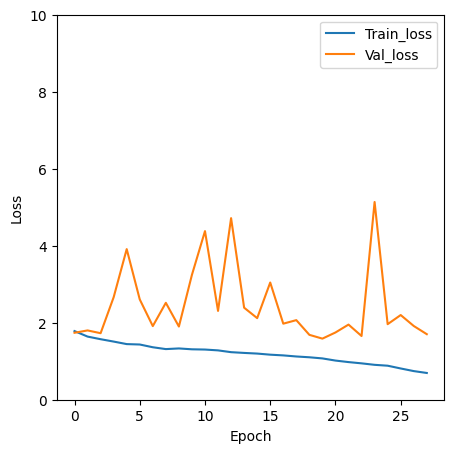

In [53]:
plt.rcParams["figure.figsize"] = (5,5)
plt.plot(md4.history['loss'], label='Train_loss')
plt.plot(md4.history['val_loss'], label='Val_loss')
plt.ylim([0, 10])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

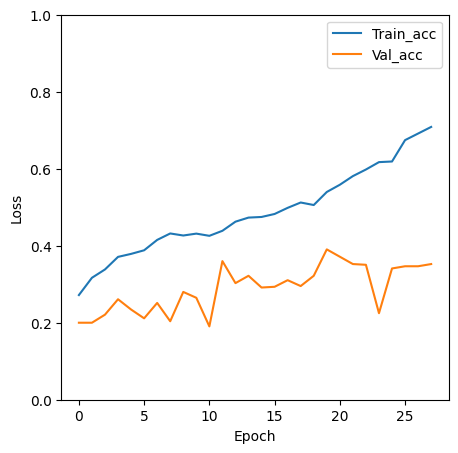

In [54]:
plt.rcParams["figure.figsize"] = (5,5)
plt.plot(md4.history['accuracy'], label='Train_acc')
plt.plot(md4.history['val_accuracy'], label='Val_acc')
plt.ylim([0, 1])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
y_pred = np.argmax(model4.predict(X_test), axis=-1)

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step


In [56]:
#Model Evaluation
print("Accuracy:",  accuracy_score(y_test, y_pred))
print("Precision Score : ",precision_score(y_test, y_pred, average='macro'))
print("Recall Score : ",recall_score(y_test, y_pred, average='macro'))
print("F1 Score : ",f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.38476190476190475
Precision Score :  0.4237517224813846
Recall Score :  0.38476190476190475
F1 Score :  0.3393731417997767


In [57]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.29      0.07      0.11       105
           1       0.59      0.10      0.16       105
           2       0.29      0.65      0.40       105
           3       0.39      0.50      0.44       105
           4       0.56      0.62      0.59       105

    accuracy                           0.38       525
   macro avg       0.42      0.38      0.34       525
weighted avg       0.42      0.38      0.34       525

[[ 7  5 73 14  6]
 [10 10 60 16  9]
 [ 4  2 68 22  9]
 [ 2  0 23 52 28]
 [ 1  0 11 28 65]]


MODEL 5

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
    fill_mode="nearest"
)

datagen.fit(X_train)

md5 = model4.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_valid, y_valid),
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.2098 - loss: 1.9064 - val_accuracy: 0.2000 - val_loss: 1.6205
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.2020 - loss: 1.8856 - val_accuracy: 0.2000 - val_loss: 1.6606
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.2020 - loss: 1.8414 - val_accuracy: 0.2000 - val_loss: 1.7867
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.2237 - loss: 1.7911 - val_accuracy: 0.2171 - val_loss: 2.1143
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.2139 - loss: 1.7828 - val_accuracy: 0.2000 - val_loss: 3.0228
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.1996 - loss: 1.7959 - val_accuracy: 0.2000 - val_loss: 5.3752
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.1951 - loss: 1.7836 - val_accuracy: 0.2000 - val_loss: 7.0239
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.1967 - loss: 1.7610 - val_accuracy: 0.2000 - val_loss:

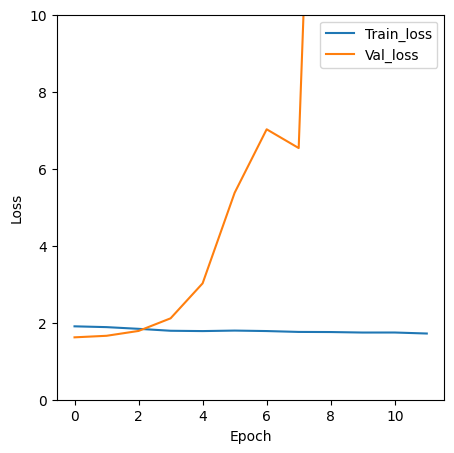

In [13]:
plt.rcParams["figure.figsize"] = (5,5)
plt.plot(md5.history['loss'], label='Train_loss')
plt.plot(md5.history['val_loss'], label='Val_loss')
plt.ylim([0, 10])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

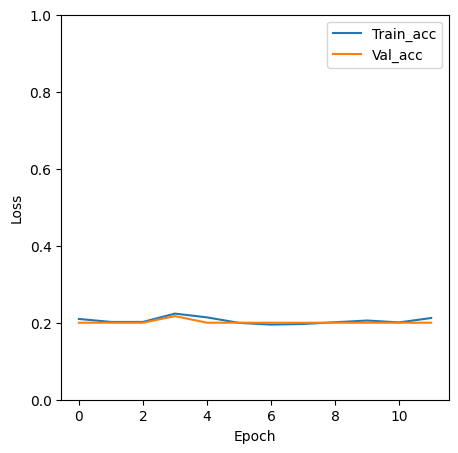

In [15]:
plt.rcParams["figure.figsize"] = (5,5)
plt.plot(md5.history['accuracy'], label='Train_acc')
plt.plot(md5.history['val_accuracy'], label='Val_acc')
plt.ylim([0, 1])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [17]:
y_pred = np.argmax(model4.predict(X_test), axis=-1)

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step


In [18]:
#Model Evaluation
print("Accuracy:",  accuracy_score(y_test, y_pred))
print("Precision Score : ",precision_score(y_test, y_pred, average='macro'))
print("Recall Score : ",recall_score(y_test, y_pred, average='macro'))
print("F1 Score : ",f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.21523809523809523
Precision Score :  0.08821239073176318
Recall Score :  0.21523809523809523
F1 Score :  0.11801187744634904


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [19]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       105
           1       0.00      0.00      0.00       105
           2       0.00      0.00      0.00       105
           3       0.23      0.30      0.26       105
           4       0.21      0.78      0.33       105

    accuracy                           0.22       525
   macro avg       0.09      0.22      0.12       525
weighted avg       0.09      0.22      0.12       525

[[ 0  0  0 28 77]
 [ 0  0  0 35 70]
 [ 0  0  0 17 88]
 [ 0  0  0 31 74]
 [ 0  0  0 23 82]]


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

model 6

In [7]:
model6 = Sequential()
num_classes = 5
input_shape = X_train[0].shape

# Block 1
model6.add(Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=input_shape))
model6.add(BatchNormalization())
model6.add(Conv2D(32, (3, 3), padding="same", activation="relu"))
model6.add(BatchNormalization())
model6.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model6.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
model6.add(BatchNormalization())
model6.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
model6.add(BatchNormalization())
model6.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model6.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
model6.add(BatchNormalization())
model6.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
model6.add(BatchNormalization())
model6.add(MaxPooling2D(pool_size=(2, 2)))

# Classifier
model6.add(GlobalAveragePooling2D())
model6.add(Dense(125, activation="relu"))
model6.add(BatchNormalization())
model6.add(Dropout(0.3))
model6.add(Dense(num_classes, activation="softmax"))

model6.summary()

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 180, 180, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 90, 90, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 125)            │        16,125 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 125)            │           500 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 125)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           630 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,055 (1.17 MB)

 Trainable params: 304,909 (1.16 MB)

 Non-trainable params: 1,146 (4.48 KB)

In [9]:
model6.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True
)

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=5,
    zoom_range=0.05,
    width_shift_range=0.03,
    height_shift_range=0.03,
    brightness_range=[0.95, 1.05],
    horizontal_flip=True,
    fill_mode="nearest"
)

datagen.fit(X_train)

md6 = model6.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_valid, y_valid),
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.2041 - loss: 1.8740 - val_accuracy: 0.2000 - val_loss: 1.6104
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.2135 - loss: 1.8368 - val_accuracy: 0.2000 - val_loss: 1.6478
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.2127 - loss: 1.8334 - val_accuracy: 0.2000 - val_loss: 1.9496
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.1988 - loss: 1.7966 - val_accuracy: 0.1790 - val_loss: 2.0141
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 77s 992ms/step - accuracy: 0.1963 - loss: 1.7980 - val_accuracy: 0.2000 - val_loss: 3.0924
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 76s 984ms/step - accuracy: 0.2082 - loss: 1.7948 - val_accuracy: 0.2000 - val_loss: 5.0593
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 76s 990ms/step - accuracy: 0.2008 - loss: 1.7714 - val_accuracy: 0.2000 - val_loss: 9.5792
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 77s 998ms/step - accuracy: 0.1980 - loss: 1.7740 - val_accuracy: 0.2000

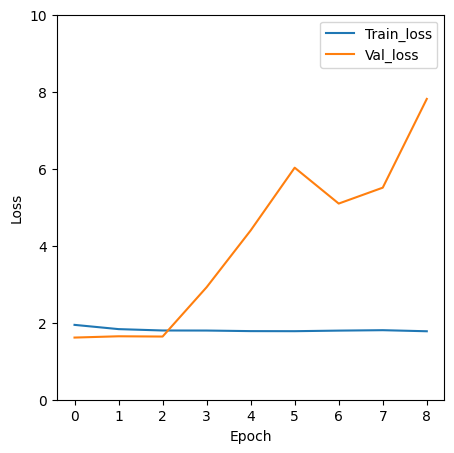

In [13]:
plt.rcParams["figure.figsize"] = (5,5)
plt.plot(md6.history['loss'], label='Train_loss')
plt.plot(md6.history['val_loss'], label='Val_loss')
plt.ylim([0, 10])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

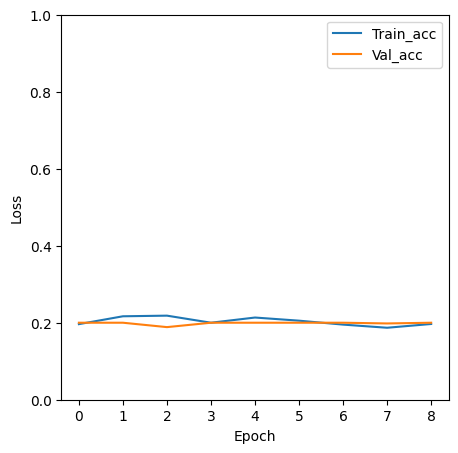

In [14]:
plt.rcParams["figure.figsize"] = (5,5)
plt.plot(md6.history['accuracy'], label='Train_acc')
plt.plot(md6.history['val_accuracy'], label='Val_acc')
plt.ylim([0, 1])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [15]:
y_pred = np.argmax(model4.predict(X_test), axis=-1)

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step


In [16]:
#Model Evaluation
print("Accuracy:",  accuracy_score(y_test, y_pred))
print("Precision Score : ",precision_score(y_test, y_pred, average='macro'))
print("Recall Score : ",recall_score(y_test, y_pred, average='macro'))
print("F1 Score : ",f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.2
Precision Score :  0.04
Recall Score :  0.2
F1 Score :  0.06666666666666667


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [17]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       105
           1       0.00      0.00      0.00       105
           2       0.00      0.00      0.00       105
           3       0.00      0.00      0.00       105
           4       0.20      1.00      0.33       105

    accuracy                           0.20       525
   macro avg       0.04      0.20      0.07       525
weighted avg       0.04      0.20      0.07       525

[[  0   0   0   0 105]
 [  0   0   0   0 105]
 [  0   0   0   0 105]
 [  0   0   0   0 105]
 [  0   0   0   0 105]]


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize